<a href="https://colab.research.google.com/github/MuBasHarAkBar/Real-time-face-mask-detection-using-MobileNetV2-transfer-learning-and-OpenCV-Haar-cascade./blob/main/Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
import os, random, shutil, glob
import xml.etree.ElementTree as ET
import cv2, numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files
from google.colab.patches import cv2_imshow

In [11]:
IMG_DIR = "/content/raw/images"
ANN_DIR = "/content/raw/annotations"
OUT_DIR = "/content/faces"
PAD = 0.20          # same padding as the detection code
MIN_SIZE = 24       # skip tiny faces
class_map = {"with_mask": "with_mask", "without_mask": "without_mask"}

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
for split in ["train", "val"]:
    for c in class_map.values():
        os.makedirs(f"{OUT_DIR}/{split}/{c}", exist_ok=True)

xml_files = sorted(glob.glob(f"{ANN_DIR}/*.xml"))
random.seed(42)
random.shuffle(xml_files)
n_val = int(0.2 * len(xml_files))
val_set = set(xml_files[:n_val])

counts = {}
for xml_path in xml_files:
    split = "val" if xml_path in val_set else "train"
    root = ET.parse(xml_path).getroot()
    img_name = root.find("filename").text
    img = cv2.imread(os.path.join(IMG_DIR, img_name))
    if img is None:
        continue
    H, W = img.shape[:2]
    for i, obj in enumerate(root.findall("object")):
        name = obj.find("name").text
        if name not in class_map:
            continue
        bb = obj.find("bndbox")
        x1, y1 = int(float(bb.find("xmin").text)), int(float(bb.find("ymin").text))
        x2, y2 = int(float(bb.find("xmax").text)), int(float(bb.find("ymax").text))
        w, h = x2 - x1, y2 - y1
        if w < MIN_SIZE or h < MIN_SIZE:
            continue
        pw, ph = int(w * PAD), int(h * PAD)
        x1, y1 = max(0, x1 - pw), max(0, y1 - ph)
        x2, y2 = min(W, x2 + pw), min(H, y2 + ph)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop = cv2.resize(crop, (160, 160), interpolation=cv2.INTER_AREA)
        stem = os.path.splitext(img_name)[0]
        cv2.imwrite(f"{OUT_DIR}/{split}/{class_map[name]}/{stem}_{i}.jpg", crop)
        counts[(split, name)] = counts.get((split, name), 0) + 1

for k, v in sorted(counts.items()):
    print(k, v)

('train', 'with_mask') 1181
('train', 'without_mask') 203
('val', 'with_mask') 287
('val', 'without_mask') 43


In [12]:
 IMG_SIZE = 160
BATCH = 32
CLASSES = ["with_mask", "without_mask"]

train_raw = tf.keras.utils.image_dataset_from_directory(
    f"{OUT_DIR}/train", class_names=CLASSES, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, shuffle=True, seed=42)
val_raw = tf.keras.utils.image_dataset_from_directory(
    f"{OUT_DIR}/val", class_names=CLASSES, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, shuffle=False)

print("Classes:", train_raw.class_names)

# Class weights (with_mask has many more images than without_mask)
n0 = len(os.listdir(f"{OUT_DIR}/train/with_mask"))
n1 = len(os.listdir(f"{OUT_DIR}/train/without_mask"))
total = n0 + n1
class_weight = {0: total / (2 * n0), 1: total / (2 * n1)}
print("Train counts:", n0, n1, "| class weights:", class_weight)

AUTOTUNE = tf.data.AUTOTUNE
prep = lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
train_ds = train_raw.map(prep, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_raw.map(prep, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 1384 files belonging to 2 classes.
Found 330 files belonging to 2 classes.
Classes: ['with_mask', 'without_mask']
Train counts: 1181 203 | class weights: {0: 0.5859441151566469, 1: 3.4088669950738915}


In [13]:
 augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
])

base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8, restore_best_weights=True)

hist1 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                  class_weight=class_weight, callbacks=[early_stop])

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.5506 - loss: 0.7852 - val_accuracy: 0.7030 - val_loss: 0.5664
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5173 - loss: 0.7833 - val_accuracy: 0.5242 - val_loss: 0.9081
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5137 - loss: 0.7741 - val_accuracy: 0.5061 - val_loss: 0.9933
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5564 - loss: 0.7291 - val_accuracy: 0.6333 - val_loss: 0.6795
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.5643 - loss: 0.7129 - val_accuracy: 0.8364 - val_loss: 0.3626
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5571 - loss: 0.7187 - val_accuracy: 0.7970 - val_loss: 0.4130
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5564 - loss: 0.7144 - val_accuracy: 0.5939 - val_loss: 0.7491
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5903 - loss: 0.6917 - val_accuracy: 0

In [15]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8, restore_best_weights=True)

hist2 = model.fit(train_ds, validation_data=val_ds, epochs=50,
                  class_weight=class_weight, callbacks=[early_stop2])

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - accuracy: 0.7392 - loss: 0.9208 - val_accuracy: 0.8879 - val_loss: 0.3196
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.5990 - loss: 0.8092 - val_accuracy: 0.8909 - val_loss: 0.3039
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5759 - loss: 0.7819 - val_accuracy: 0.8909 - val_loss: 0.2983
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5347 - loss: 0.7455 - val_accuracy: 0.8909 - val_loss: 0.2922
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5694 - loss: 0.6946 - val_accuracy: 0.8970 - val_loss: 0.2855
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6062 - loss: 0.7039 - val_accuracy: 0.8909 - val_loss: 0.2883
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5629 - loss: 0.7242 - val_accuracy: 0.8848 - val_loss: 0.2898
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6069 - loss: 0.6699 - val_accuracy: 0.8879 -

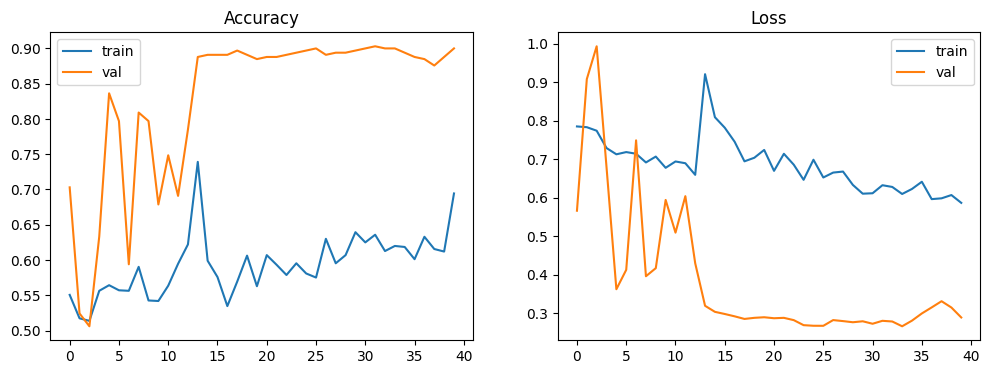

Confusion matrix:
 [[270  17]
 [ 15  28]]
              precision    recall  f1-score   support

        Mask       0.95      0.94      0.94       287
     No Mask       0.62      0.65      0.64        43

    accuracy                           0.90       330
   macro avg       0.78      0.80      0.79       330
weighted avg       0.91      0.90      0.90       330



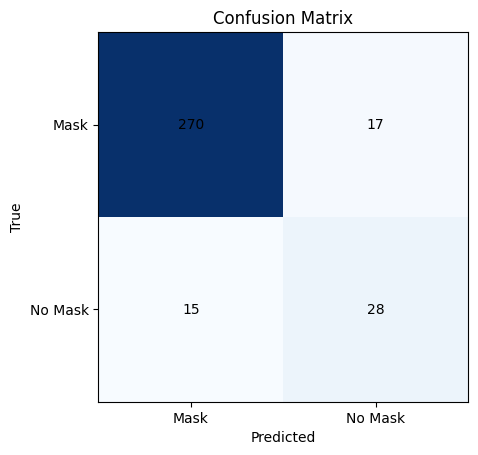

In [16]:
acc = hist1.history["accuracy"] + hist2.history["accuracy"]
val_acc = hist1.history["val_accuracy"] + hist2.history["val_accuracy"]
loss = hist1.history["loss"] + hist2.history["loss"]
val_loss = hist1.history["val_loss"] + hist2.history["val_loss"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(acc, label="train"); ax[0].plot(val_acc, label="val"); ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(loss, label="train"); ax[1].plot(val_loss, label="val"); ax[1].set_title("Loss"); ax[1].legend()
plt.savefig("training_curves.png", dpi=150); plt.show()

y_true = np.concatenate([y.numpy() for _, y in val_ds])
y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_true, y_pred, target_names=["Mask", "No Mask"]))

plt.imshow(cm, cmap="Blues"); plt.title("Confusion Matrix")
plt.xticks([0, 1], ["Mask", "No Mask"]); plt.yticks([0, 1], ["Mask", "No Mask"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig("confusion_matrix.png", dpi=150); plt.show()

In [17]:
# Build an inference-only model (no augmentation) that reuses the trained weights
gap, drop, dense = model.layers[-3], model.layers[-2], model.layers[-1]

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inp, training=False)
x = gap(x)
x = drop(x)
out = dense(x)
infer_model = models.Model(inp, out)

# Quick check: predictions should match the trained model
sample = next(iter(val_ds))[0][:4]
print("Max difference:", np.abs(model.predict(sample, verbose=0) - infer_model.predict(sample, verbose=0)).max())

infer_model.save("mask_classifier_mobilenet.h5")
infer_model.save("mask_classifier_mobilenet.keras")   # backup in the new format

print(os.path.exists("mask_classifier_mobilenet.h5"))
files.download("mask_classifier_mobilenet.h5")
files.download("training_curves.png")
files.download("confusion_matrix.png")

Max difference: 8.6426735e-07
True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import os, cv2, numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from google.colab import files
from google.colab.patches import cv2_imshow

if not os.path.exists("mask_classifier_mobilenet.h5"):
    files.upload()   # choose mask_classifier_mobilenet.h5

model = load_model("mask_classifier_mobilenet.h5", compile=False)
labels = ["Mask", "No Mask"]   # with_mask = 0, without_mask = 1
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
PADDING_RATIO = 0.20

def detect_and_draw(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        pw, ph = int(w * PADDING_RATIO), int(h * PADDING_RATIO)
        x1, y1 = max(0, x - pw), max(0, y - ph)
        x2, y2 = min(frame.shape[1], x + w + pw), min(frame.shape[0], y + h + ph)
        face_bgr = frame[y1:y2, x1:x2]
        if face_bgr.size == 0:
            continue
        face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
        face_rgb = cv2.resize(face_rgb, (160, 160), interpolation=cv2.INTER_AREA)
        face_input = np.expand_dims(preprocess_input(face_rgb.astype(np.float32)), 0)
        preds = model.predict(face_input, verbose=0)[0]
        cls = int(np.argmax(preds))
        color = (0, 255, 0) if cls == 0 else (0, 0, 255)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
        cv2.putText(frame, f"{labels[cls]} ({preds[cls]:.2f})", (x1, max(20, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return frame, len(faces)

print("Model loaded.")

Model loaded.


Saving maksssksksss53.png to maksssksksss53.png
maksssksksss53.png: 0 face(s) found


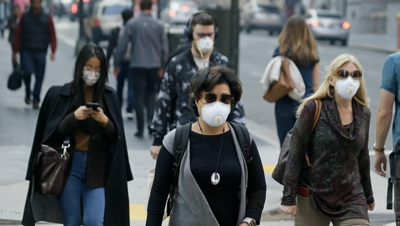

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
img_files = files.upload()
for name in img_files:
    frame = cv2.imread(name)
    if frame is None:
        print(f"Could not read {name}")
        continue
    result, n = detect_and_draw(frame)
    print(f"{name}: {n} face(s) found")
    cv2_imshow(result)
    cv2.imwrite("result_" + name, result)
    files.download("result_" + name)   # saves the result image for your README

In [21]:
vid = files.upload()
video_name = list(vid.keys())[0]
cap = cv2.VideoCapture(video_name)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
w, h = int(cap.get(3)), int(cap.get(4))
out = cv2.VideoWriter("output_video.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(detect_and_draw(frame)[0])
cap.release(); out.release()
files.download("output_video.mp4")

Saving 16c60edb6d4a59fd912a451b24eed57d.mp4 to 16c60edb6d4a59fd912a451b24eed57d (1).mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>